In [1]:
from astrovision.plot.plot_utils import make_mosaic
from astrovision.data import SatelliteImage, SegmentationLabeledSatelliteImage
import s3fs

In [2]:
fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://" + "minio.lab.sspcloud.fr"})
fs.download(rpath="projet-slums-detection/ilots", lpath="ilots", recursive=True)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [3]:
fs.download(rpath="projet-slums-detection/data-prediction/PLEIADES/MAYOTTE", lpath="pred_mayotte", recursive=True)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [7]:
import os
import geopandas as gpd

# Open the .gpkg file
pred_2020 = gpd.read_file('pred_mayotte/2020/predictions.gpkg')
pred_2023 = gpd.read_file('pred_mayotte/2023/predictions.gpkg')
# Print the GeoDataFrame
print(pred_2020.head())

                                            filename id  \
0  projet-slums-detection/data-raw/PLEIADES/MAYOT...  0   
1  projet-slums-detection/data-raw/PLEIADES/MAYOT...  1   
2  projet-slums-detection/data-raw/PLEIADES/MAYOT...  2   
3  projet-slums-detection/data-raw/PLEIADES/MAYOT...  3   
4  projet-slums-detection/data-raw/PLEIADES/MAYOT...  4   

                                            geometry  
0  POLYGON ((502603.000 8601994.500, 502604.500 8...  
1  POLYGON ((502548.000 8601986.500, 502550.000 8...  
2  POLYGON ((502596.000 8601974.500, 502601.000 8...  
3  POLYGON ((502591.000 8601970.500, 502591.000 8...  
4  POLYGON ((502602.500 8601981.000, 502606.000 8...  


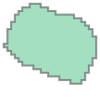

In [13]:
pred_2020.geometry.iloc[5]

In [8]:
pred_2020.crs

<Projected CRS: EPSG:4471>
Name: RGM04 / UTM zone 38S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Mayotte - onshore and offshore.
- bounds: (43.68, -14.49, 46.7, -11.33)
Coordinate Operation:
- name: UTM zone 38S
- method: Transverse Mercator
Datum: Reseau Geodesique de Mayotte 2004
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [9]:
from pyproj import CRS
tgt_crs = CRS.from_epsg(4326)
pred_2020 = pred_2020.to_crs(tgt_crs)
pred_2023 = pred_2023.to_crs(tgt_crs)

In [17]:
center

NameError: name 'center' is not defined

In [18]:
! pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.0/100.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.0/82.0 kB 21.1 MB/s eta 0:00:00


In [19]:
import folium

# Create a Folium map centered on the first polygon in the GeoDataFrame
center = list(pred_2020.iloc[0]['geometry'].centroid.coords)[0]

# initialisation de la carte
m = folium.Map(location=center, zoom_start=10)

# Add a GeoJSON layer from the GeoDataFrame to the map
folium.GeoJson(pred_2020).add_to(m)

In [ ]:
m